# MultinomialNB এটা text বা NLP তে ভালো কাজ করে

## high dimansion বা অনেক বেশি features যেমন 3000/4000 features থাকলেও ভালো কাজ করে

In [1]:
# ===============================================================
# Imports and basic setup
# ===============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_20newsgroups
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB, MultinomialNB
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (7, 4)

In [2]:
categories= ['comp.graphics', 'rec.sport.baseball', 'sci.med'] # আমরা এ ৩ টা নিয়ে কাজ করব বাকি গুলা নিব না ।সব গুলা নিয়ে NLP যখন করব তখন দেখব

newsgroups= fetch_20newsgroups(
    subset= 'train',
    categories=categories,
    remove=('headers', 'footers', 'quotes'),
    shuffle=True,
    random_state=42
)

df= pd.DataFrame({
    'text': newsgroups.data,
    'label': newsgroups.target
})

df.head()

,text,label
0,"\nThe FDA, I believe. Rules say no blood or b...",2
1,,2
2,It would be nice to think that individuals can...,2
3,"Ok all you trivia buffs, I have a good one for...",1
4,"Please , I need the starting address (pointer)...",0


In [3]:
print('Number of documents: ',len(newsgroups.data))
print('Target names: ',newsgroups.target_names)

Number of documents:  1775
Target names:  ['comp.graphics', 'rec.sport.baseball', 'sci.med']


In [4]:
# train test split
X_train, X_test, y_train, y_test= train_test_split(df['text'], df['label'], test_size=0.25, random_state=42)

print('Train size: ',X_train.shape[0])
print('Test size: ',X_test.shape[0])

Train size:  1331
Test size:  444


In [5]:
# CountVectorizer
vectorizer= CountVectorizer(stop_words='english', max_features=3000) # আমরা top 3000 features নিব, বাকি গুলা নিব না। তাহলে অনেক বড় হয়ে যাবে। সেটা NLP তে নিব
X_train_counts= vectorizer.fit_transform(X_train)
X_test_counts= vectorizer.transform(X_test)

print('Shape of X_train_counts:', X_train_counts.shape)
print('Shape of X_test_counts:', X_test_counts.shape)

Shape of X_train_counts: (1331, 3000)
Shape of X_test_counts: (444, 3000)


In [6]:
mnb= MultinomialNB()
mnb.fit(X_train_counts, y_train)

MultinomialNB()

Acuracy:  0.9166666666666666
Confusion matrix:
 [[131   5   7]
 [  6 132   9]
 [  4   6 144]]


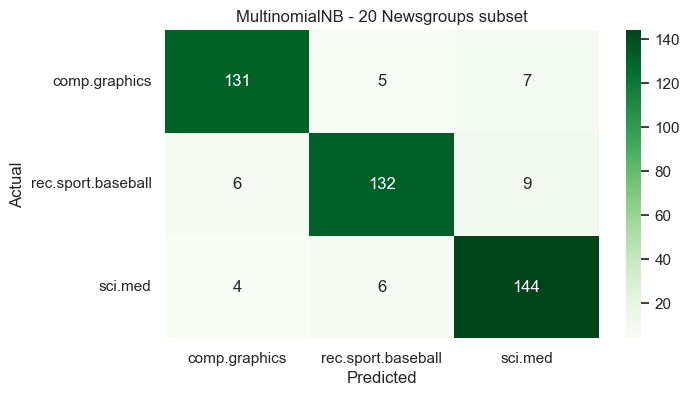

In [8]:
y_pred= mnb.predict(X_test_counts)
acc= accuracy_score(y_test, y_pred)
print('Acuracy: ',acc)

cm= confusion_matrix(y_test, y_pred)
print('Confusion matrix:\n',cm)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=newsgroups.target_names,
    yticklabels=newsgroups.target_names
)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('MultinomialNB - 20 Newsgroups subset')
plt.show()

In [9]:
print('================Classification report================\n')
print(classification_report(y_test, y_pred, target_names=newsgroups.target_names))

================Classification report================

                    precision    recall  f1-score   support

     comp.graphics       0.93      0.92      0.92       143
rec.sport.baseball       0.92      0.90      0.91       147
           sci.med       0.90      0.94      0.92       154

          accuracy                           0.92       444
         macro avg       0.92      0.92      0.92       444
      weighted avg       0.92      0.92      0.92       444

